# Normalizing flows verification: architecture

The goal of this notebook is to verify that normalizing flows is appropriate for transforming different distributions into a normal distribution while maintaining outlier structure.

In [0]:
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import normflows as nf
from tqdm.notebook import tqdm

from scipy import stats

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

import shap

import seaborn as sns
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt


In [0]:
sns.set_theme(style='white')

We define the main function to estimate the bijection to map from the complex \\(X\\)-space to the base distribution (Gaussian) \\(Z\\)-space. Note that the loss function is the sum of the \\(KL\\)-divergence and penalized by penalized by the logarithm of the non-unit Jacobian of the bijection squared with parameter \\(\lambda\\) in order to reduce wiggliness of the bijection. We attempt to match the target distribution (i.e. the Moons \\(p_\mathbf{X}(\mathbf{x}; \bm{\theta})\\)) with a flow-based model \\(p^*_\mathbf{X}(\mathbf{x}; \bm{\theta})\\) while penalizing for large movements required to approximate normality.

\\[\mathcal{L} = D_{KL}\left[ p^*_\mathbf{X}(\mathbf{x}) \|| p_\mathbf{X}(\mathbf{x}; \bm{\theta})\right] + \lambda \log^2 (|\det J(f|z)|), \\]

where \\(J\\) is the matrix of first derivatives (Jacobian) of \\(f\\).

In [0]:
def norm_flow(input_data, K, hidden_layers, hidden_units, iter, lam):

    # Number of bijections
    K = K

    # Latent size
    latent_size = input_data.shape[1]

    # NN architecture
    hidden_units = hidden_units
    hidden_layers = hidden_layers

    # Scale input data
    scaler = StandardScaler()
    input_data = scaler.fit_transform(input_data)

    # Set up the flows
    flows = []
    for i in range(K):
        flows += [nf.flows.AutoregressiveRationalQuadraticSpline(latent_size, hidden_layers, hidden_units, permute_mask=True, init_identity=True)]
        flows += [nf.flows.ActNorm(latent_size)]

    # Set base distribution
    q0 = nf.distributions.DiagGaussian(latent_size, trainable=False)
        
    # Construct flow model
    mod = nf.NormalizingFlow(q0, flows)

    device = torch.device('cuda')
    
    # Move model on GPU if available
    mod = mod.to(device)

    # Train model
    max_iter = iter
    optimizer = torch.optim.AdamW(mod.parameters(), lr=3e-4)

    x = torch.tensor(input_data, dtype=torch.float32, device=device)
    
    for it in tqdm(range(max_iter), desc='Normflow', position=1):
        optimizer.zero_grad()

        # Define the loss function
        _, jac = mod.inverse_and_log_det(x)
        loss = mod.forward_kld(x) + lam*torch.mean(jac**2)
        
        # Do backprop and optimizer step
        if ~(torch.isnan(loss) | torch.isinf(loss)):
            loss.backward()
            optimizer.step()

    # EZ = np.mean((x - mod.inverse(x)).to('cpu').detach().numpy()**2)
    # print("MSE from X to Z: ", EZ)
    with torch.no_grad():
        z = mod.inverse(torch.tensor(input_data, dtype=torch.float32, device=device)).to('cpu').detach().numpy()
    return mod, z

## Distribution

We begin with a 1/2\\(\mathcal{N}(5, 1)\\) + 1/2\\(\mathcal{N}(1, 1.3^2)\\) distribution as the underlying data.

In [0]:
n = 10000
np.random.seed(123)

In [0]:
# Bimodal
# Parameters of the mixture components
norm_params = np.array([[5, 1], [1, 1.3]])
n_components = norm_params.shape[0]
weights = np.ones(n_components, dtype=np.float64) / 2.0

# Sample from the mixture
mixture_idx = np.random.choice(len(weights), size=n, replace=True, p=weights)
X_bimod = np.fromiter((stats.norm.rvs(*(norm_params[i])) for i in mixture_idx), dtype=np.float64).reshape(-1, 1)

<Axes: >

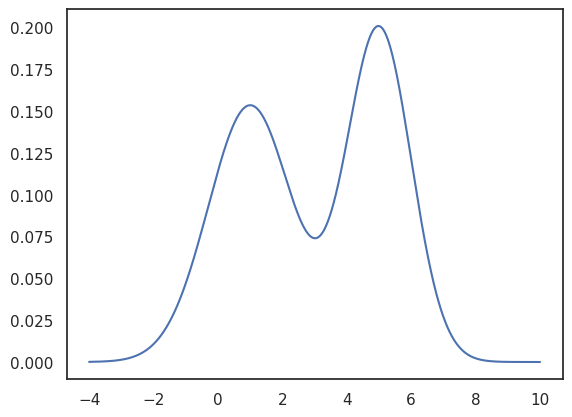

In [0]:
x = np.linspace(-4,10,1000)
sns.lineplot(x=x, y=0.5*stats.norm.pdf(x,*norm_params[0]) + 0.5*stats.norm.pdf(x,*norm_params[1]))

We apply the normalizing flow to the SHAP values by first tuning \\(\lambda\\) and then applying the flow.

In [0]:
transformations = [4, 6, 8, 16]
layers = [2, 2, 3, 3]
units = [4, 6, 16, 32]

grid = np.array([0.04, 0.045, 0.05, 0.055, 0.06,
                 0.065, 0.07, 0.075, 0.08, 0.085])

param_grid = list(zip(transformations, layers, units))

results = []

for p in tqdm(param_grid, desc="Parameter sets", position=0):
    lam = None
    jb_pval = None
    series_out = None
    mod_best, z_best = None, None

    # Search over grid
    for j, i in enumerate(grid):
        print(f"lambda: {i}")
        mod, z = norm_flow(
            X_bimod.reshape(-1, 1),
            p[0], p[1], p[2],
            500, i
        )

        jb = stats.jarque_bera(z.reshape(-1))
        print(jb)

        if jb.pvalue > 0.01:
            # keep penultimate passing
            lam = i
            jb_pval = jb.pvalue
            mod_best, z_best = mod, z
        else:
            # test failed → stop, keep previous passing z
            break

    # safeguard: if it failed on the very first grid point
    if mod_best is None:
        lam = grid[0]
        jb_pval = jb.pvalue
        mod_best, z_best = mod, z

    # if the stored z passed the test, generate transformed series
    if jb_pval > 0.01:
        x_ = np.linspace(-6, 6, 1000, dtype=np.float32).reshape(-1, 1)
        x_torch = torch.tensor(x_, device="cuda")

        with torch.no_grad():
            y_transformed = mod_best.forward(x_torch).detach().cpu().numpy().reshape(-1)

        series_out = pd.Series(y_transformed)

    results.append((lam, jb_pval, series_out))
    print(results)

# Collect into DataFrame
y_final = pd.DataFrame({
    f"run_{k}": r[2] for k, r in enumerate(results) if r[2] is not None
})

Parameter sets:   0%|          | 0/4 [00:00<?, ?it/s]

lambda: 0.04


Normflow:   0%|          | 0/500 [00:00<?, ?it/s]

SignificanceResult(statistic=5.822962871410362, pvalue=0.054395087326015765)
lambda: 0.045


Normflow:   0%|          | 0/500 [00:00<?, ?it/s]

...

SignificanceResult(statistic=8.410779046450875, pvalue=0.014914975208158272)
lambda: 0.06


Normflow:   0%|          | 0/500 [00:00<?, ?it/s]

SignificanceResult(statistic=9.116357761635784, pvalue=0.010481128958767953)
lambda: 0.065


Normflow:   0%|          | 0/500 [00:00<?, ?it/s]

SignificanceResult(statistic=10.772990409988802, pvalue=0.004577990168560355)
[(0.055, 0.011411506793367039, 0     -4.716694
1     -4.707305
2     -4.697917
3     -4.688529
4     -4.679139
         ...   
995    4.624999
996    4.634387
997    4.643776
998    4.653165
999    4.662553
Length: 1000, dtype: float32), (0.055, 0.015995888411006035, 0     -4.684223
1     -4.674902
2     -4.665582
3     -4.656260
4     -4.646940
         ...   
995    4.589843
996    4.599164
997    4.608484
998    4.617805
999    4.627126
Length: 1000, dtype: float32), (0.06, 0.012868041457307852, 0     -4.716924
1     -4.707510
2     -4.698097
3     -4.688684
4     -4.679270
         ...   
995    4.649315
996    4.658729
997    4.668142
998    4.677555
999    4.686968
Length: 1000, dtype: float32), (0.06, 0.010481128958767953, 0     -4.607023
1     -4.597858
2     -4.588692
3     -4.579527
4     -4.570362
         ...   
995    4.512416
996    4.521581
997    4.530747
998    4.539912
999    4.549077
Length

In [0]:
y_final

,run_0,run_1,run_2,run_3
0,-4.716694,-4.684223,-4.716924,-4.607023
1,-4.707305,-4.674902,-4.707510,-4.597858
2,-4.697917,-4.665582,-4.698097,-4.588692
3,-4.688529,-4.656260,-4.688684,-4.579527
4,-4.679139,-4.646940,-4.679270,-4.570362
...,...,...,...,...
995,4.624999,4.589843,4.649315,4.512416
996,4.634387,4.599164,4.658729,4.521581
997,4.643776,4.608484,4.668142,4.530747
998,4.653165,4.617805,4.677555,4.539912


In [0]:
lam = [item[0] for item in results]
pval = [item[1] for item in results]
y_final_plot = y_final.copy()
y_final_plot['x'] = np.linspace(-6, 6, 1000)

In [0]:
y_final_plot.columns = ['0', '1', '2', '3', 'x']

In [0]:
lam

[0.055, 0.055, 0.06, 0.06]

In [0]:
pval

[0.011411506793367039,
 0.015995888411006035,
 0.012868041457307852,
 0.010481128958767953]

We calculate and plot the transformation with varying the random seed as well as using the bootstrap.

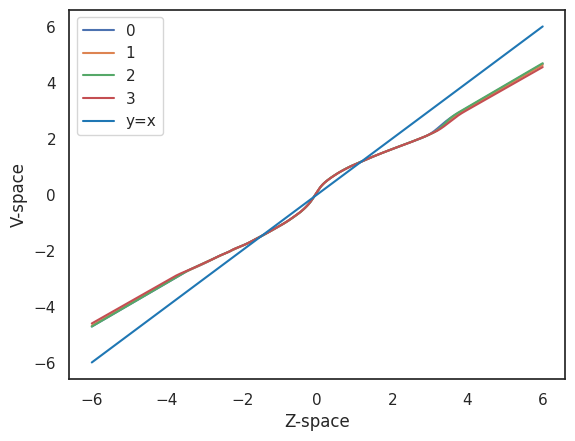

In [0]:
# Plotting transformation with varying seed
x_min = -6
y_min = -6
x_max = 6
y_max = 6

sns.lineplot(data=y_final_plot.melt(id_vars='x'), 
             x="x", 
             y="value", 
             hue='variable', 
             legend=True) \
                 .set(xlabel='Z-space', ylabel='V-space')



plt.plot([x_min,x_max],[y_min,y_max], label='y=x', color='#1f77b4')
plt.legend(loc="upper left")